# Import Libraries

In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

In [3]:
listener_data = pd.DataFrame({
"weekly_listening_hours": 
    [9.4,3.0,4.6,29.3,27.2,9.6,31.9,16.8,8.2,12.3,4.7,8.8,32.3,8.2,21.8,1.4,5.8,25.3,22.7,22.2,15.7,2.2,31.5,25.1,2.5,12.3,32.4,4.7,4.0,25.9,4.8,3.3,2.2,4.4,11.1,12.7,17.6,11.5,24.2,17.1,23.9,14.7,5.0,3.1,17.7,20.3,30.2,5.5],
"followed_genres_count": 
[5,1,3,11,14,7,11,7,4,8,1,4,12,7,12,3,1,14,11,10,6,2,12,12,1,6,14,1,3,8,3,3,1,2,6,5,4,5,12,5,14,5,2,3,7,8,12,3]
})

listener_data.head()

,weekly_listening_hours,followed_genres_count
0,9.4,5
1,3.0,1
2,4.6,3
3,29.3,11
4,27.2,14


In [4]:
listener_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   weekly_listening_hours  48 non-null     float64
 1   followed_genres_count   48 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 900.0 bytes


In [5]:
listener_data.shape

(48, 2)

# Train Clustering

In [10]:
import os

os.environ["LOKY_MAX_CPU_COUNT"] = "8"

In [14]:
kmeans_pipline = make_pipeline(
    StandardScaler(),
    KMeans(n_clusters=3, random_state=42)
)
kmeans_pipline

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('kmeans', KMeans(n_clusters=3, random_state=42))])

In [15]:
kmeans_pipline.fit(listener_data)

C:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('kmeans', KMeans(n_clusters=3, random_state=42))])

In [17]:
listener_data['target'] = kmeans_pipline[1].labels_
listener_data.head()

,weekly_listening_hours,followed_genres_count,target
0,9.4,5,2
1,3.0,1,1
2,4.6,3,1
3,29.3,11,0
4,27.2,14,0


# Plot Dataset

In [39]:
scaler = kmeans_pipline.named_steps["standardscaler"]
listener_data[['weekly_listening_hours', 'followed_genres_count']] = scaler.transform(listener_data[['weekly_listening_hours', 'followed_genres_count']])
listener_data.head()

,weekly_listening_hours,followed_genres_count,target
0,-0.505717,-0.352337,2
1,-1.153306,-1.305135,1
2,-0.991409,-0.828736,1
3,1.507877,1.076860,0
4,1.295387,1.791458,0


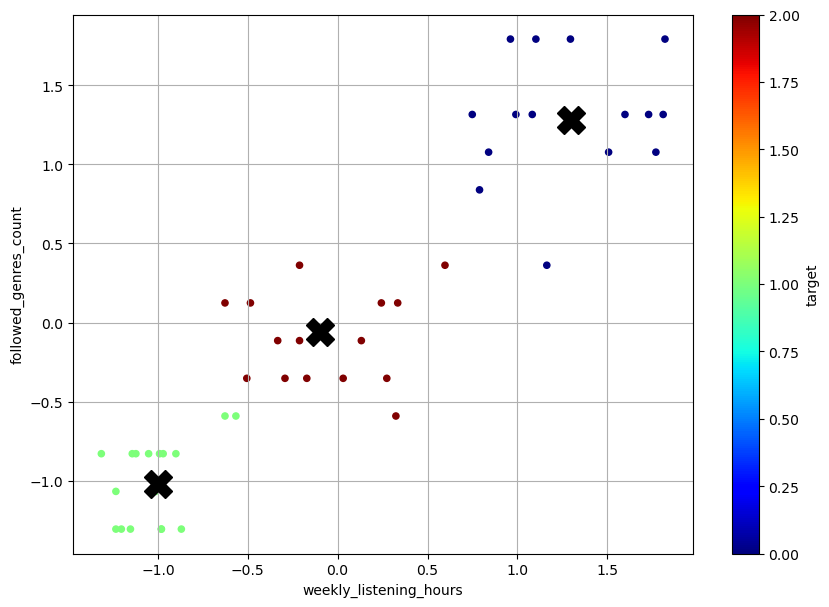

In [40]:
listener_data.plot(kind='scatter', x='weekly_listening_hours', y='followed_genres_count', c='target',
                  grid=True, cmap="jet", colorbar=True,
                     legend=True, sharex=False, figsize=(10, 7))
plt.plot(kmeans_pipline[1].cluster_centers_[:, 1], kmeans_pipline[1].cluster_centers_[:, 0], linestyle="", 
         color="black", marker="X", markersize=20, label="Cluster centers")
plt.show()

# Report Centroids

In [52]:
kmeans = kmeans_pipline.named_steps['kmeans']
scaler.mean_

array([14.39791667,  6.47916667])

In [53]:
df = pd.DataFrame(kmeans.cluster_centers_, columns=['weekly_listening_hours_center', 'followed_genres_count_center'])

df

,weekly_listening_hours_center,followed_genres_count_center
0,1.281221,1.299180
1,-1.017267,-1.000769
2,-0.060501,-0.098257


In [67]:
df = pd.DataFrame()
df['weekly_listening_hours_mean'] = [listener_data[listener_data.target == i]['weekly_listening_hours'].mean() for i in range(3)]
df['followed_genres_count_mean'] = [listener_data[listener_data.target == i]['followed_genres_count'].mean() for i in range(3)]
df['count'] = [listener_data[listener_data.target == i]['target'].count() for i in range(3)]
df

,weekly_listening_hours_mean,followed_genres_count_mean,count
0,1.281221,1.299180,15
1,-1.017267,-1.000769,18
2,-0.060501,-0.098257,15


In [68]:
df = (
    listener_data
    .groupby("target")
    .agg(
        weekly_listening_hours_mean=("weekly_listening_hours", "mean"),
        followed_genres_count_mean=("followed_genres_count", "mean"),
        count=("target", "count")
    )
    .reset_index(drop=True)
)
df

,weekly_listening_hours_mean,followed_genres_count_mean,count
0,1.281221,1.299180,15
1,-1.017267,-1.000769,18
2,-0.060501,-0.098257,15


# Reason

In [69]:
df['class names'] = ['Proffesional Listener', 'Occasional Listener', 'Normal Listener']
df

,weekly_listening_hours_mean,followed_genres_count_mean,count,class names
0,1.281221,1.299180,15,Proffesional Listener
1,-1.017267,-1.000769,18,Occasional Listener
2,-0.060501,-0.098257,15,Normal Listener


برچسبهای 0 و 1 و 2 صرفا نامهایی هستند که به هر خوشه نسبت داده می‌شوند و هیچ معنای دیگری ندارند. نه نشانگر وزن هستند و نه اهمیت.

اگر مدل دوباره اجرا شود ممکن است یک در ترتیب انتخاب تصادفی مراکز خوشه، جابجایی رخ دهد و ترتیب 0 و 1 و 2 متفاوت از مورد بالا باشد.

ما برچسبی نداریم تا از معیارهای مورد استفاده در طبقه‌بندی استفاده کنیم.

In [21]:
def train_plot_knn(listener_data, k):
    data = listener_data.copy()
    kmeans_pipline = make_pipeline(
        StandardScaler(),
        KMeans(n_clusters=k, random_state=42)
    )
    kmeans_pipline.fit(data)
    data['target'] = kmeans_pipline[1].labels_
    scaler = kmeans_pipline.named_steps["standardscaler"]
    data[['weekly_listening_hours', 'followed_genres_count']] = scaler.transform(data[['weekly_listening_hours', 'followed_genres_count']])
    data.plot(kind='scatter', x='weekly_listening_hours', y='followed_genres_count', c='target',
                  grid=True, cmap="jet", colorbar=True,
                     legend=True, sharex=False, figsize=(10, 7))
    plt.plot(kmeans_pipline[1].cluster_centers_[:, 1], kmeans_pipline[1].cluster_centers_[:, 0], linestyle="", 
             color="black", marker="X", markersize=20, label="Cluster centers")
    plt.show()

In [22]:
listener_data = pd.DataFrame({
"weekly_listening_hours": 
    [9.4,3.0,4.6,29.3,27.2,9.6,31.9,16.8,8.2,12.3,4.7,8.8,32.3,8.2,21.8,1.4,5.8,25.3,22.7,22.2,15.7,2.2,31.5,25.1,2.5,12.3,32.4,4.7,4.0,25.9,4.8,3.3,2.2,4.4,11.1,12.7,17.6,11.5,24.2,17.1,23.9,14.7,5.0,3.1,17.7,20.3,30.2,5.5],
"followed_genres_count": 
[5,1,3,11,14,7,11,7,4,8,1,4,12,7,12,3,1,14,11,10,6,2,12,12,1,6,14,1,3,8,3,3,1,2,6,5,4,5,12,5,14,5,2,3,7,8,12,3]
})

C:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


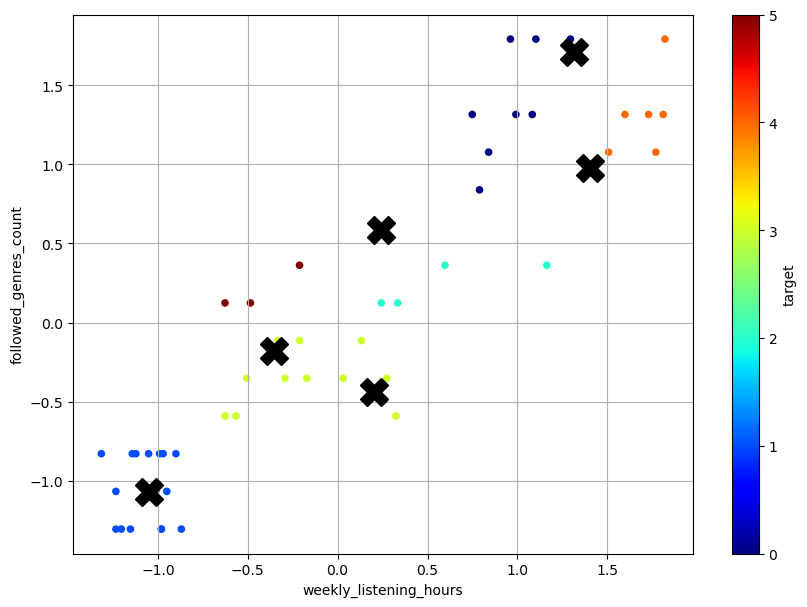

In [23]:
train_plot_knn(listener_data, 6)

C:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


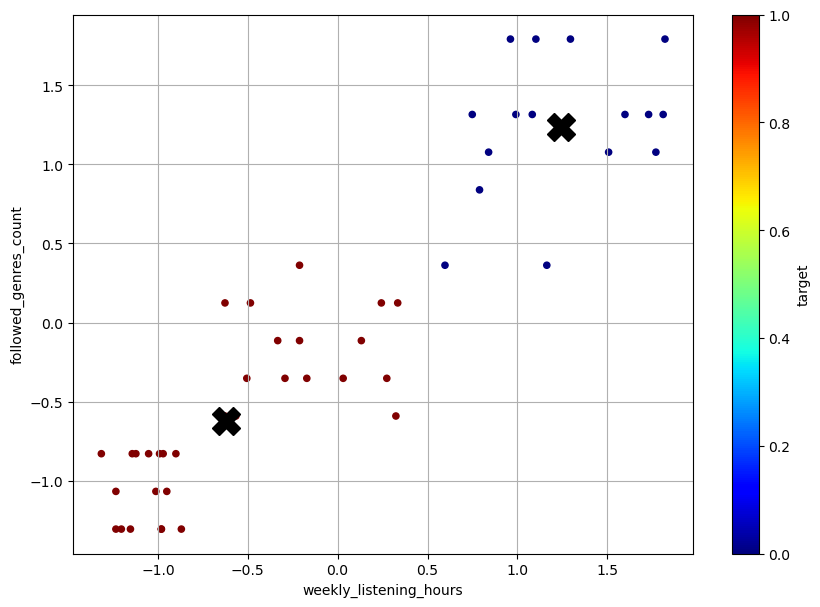

In [24]:
train_plot_knn(listener_data, 2)

C:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Anaconda\Lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (47) found smaller than n_clusters (48). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


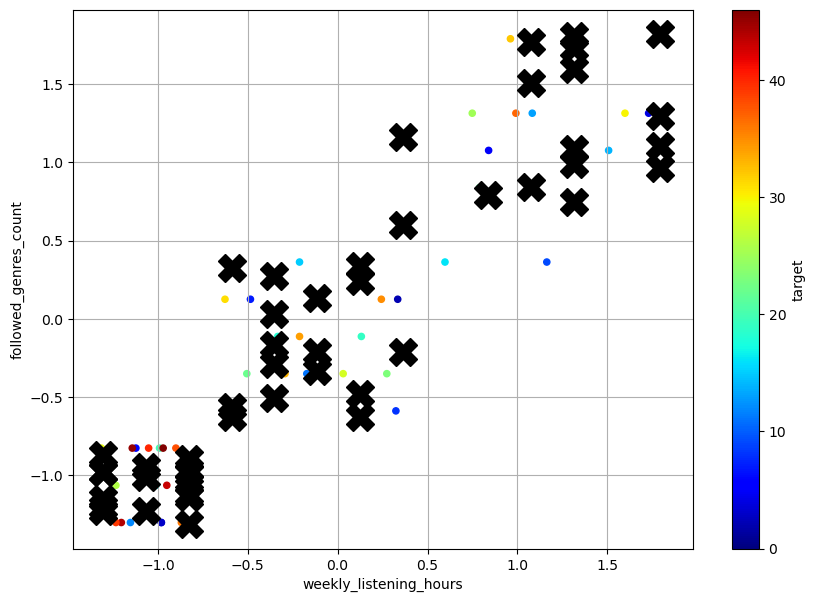

In [25]:
train_plot_knn(listener_data, 48)

استفاده از خوشه‌های زیاد به مانند مدلهای طبقه‌بندی نیست که به دنبال آن پیچیدگی و قدرت یادگیری مدل افزایش یابد. مدل اینجا فکر می‌کند قرار است به تعداد خوشه‌های پیشنهادی، داده‌ها را به گروهها و خوشه‌ها تقسیم کند. برای مثال قبلا ما خوشه لبنیات داشتیم و الان آن را به شیر و خامه و ماست و پنیر جدا کرده. یا حتی ممکن است شیرها را بر فرض بر حسب وزن یا شرکت تولید کننده جدا کند که این خوشایند ما ممکن است نباشد.